# Primer intento:

Intento basado en comprobar si es palindromo mediante divisiones enteras para extraer los digitos a todo doble producto de 100 a 999

In [1]:
def primer_intento():
    resultado = 0
    for i in range(999,100,-1):
        for j in range(999,100,-1):
            if es_palindromo(i*j):
                if i*j > resultado:
                    resultado = i*j
    return resultado

def es_palindromo(entero): # 10_000, 998_001
    if entero > 99_999:
        return (entero // 100_000 - entero // 1_000_000 * 10 == entero - entero // 10 * 10) and (entero // 10_000 - entero // 100_000 * 10 == entero // 10 - entero // 100 * 10) and (entero // 1_000 - entero // 10_000 * 10 == entero // 100 - entero // 1_000 * 10)
    else:
        return (entero // 10_000 - entero // 100_000 * 10 == entero - entero // 10 * 10) and (entero // 1_000 - entero // 10_000 * 10 == entero // 10 - entero // 100 * 10)
        
primer_intento()

906609

# Optimizacion:

chatgpt recomienda recorrer los factores de mayor a menor y podar la busqueda cuando el producto actual ya no puede superar el mejor palindromo encontrado:

In [2]:
def optimizacion():
    resultado = 0
    for i in range(999, 99, -1):
        if i * 999 <= resultado:
            break
        for j in range(i, 99, -1):
            producto = i * j
            if producto <= resultado:
                break
            if str(producto) == str(producto)[::-1]:
                resultado = producto
                break
    return resultado
optimizacion()

906609

# Comparacion:

Esta celda compara ambos metodos en tiempo y memoria.


--- Primer intento ---
Resultado: 906609
Consistente: True
Repeticiones por corrida: 1
Tiempo promedio:  104.0715 ms
Tiempo mediano:   104.0875 ms
Tiempo minimo:    103.5528 ms
Tiempo stdev:     400.0499 us  (CV: 0.4%)
Memoria promedio: 1.1797 KB
Memoria mediana:  1.1875 KB
Memoria maxima:   1.2656 KB
Memoria stdev:    80.0000 B
Asignaciones (mediana): 2

--- Optimizacion ---
Resultado: 906609
Consistente: True
Repeticiones por corrida: 10
Tiempo promedio:  1.3185 ms
Tiempo mediano:   1.3033 ms
Tiempo minimo:    1.2972 ms
Tiempo stdev:     37.8374 us  (CV: 2.9%)
Memoria promedio: 904.0000 B
Memoria mediana:  912.0000 B
Memoria maxima:   1008.0000 B
Memoria stdev:    95.5545 B
Asignaciones (mediana): 2

=== Comparacion directa ===
Speedup en tiempo:    79.87x  (gana: Optimizacion)
Ratio de memoria:     1.33x  (gana: Optimizacion)
Ratio asignaciones:   1.00x  (gana: Primer intento, menos = mejor)


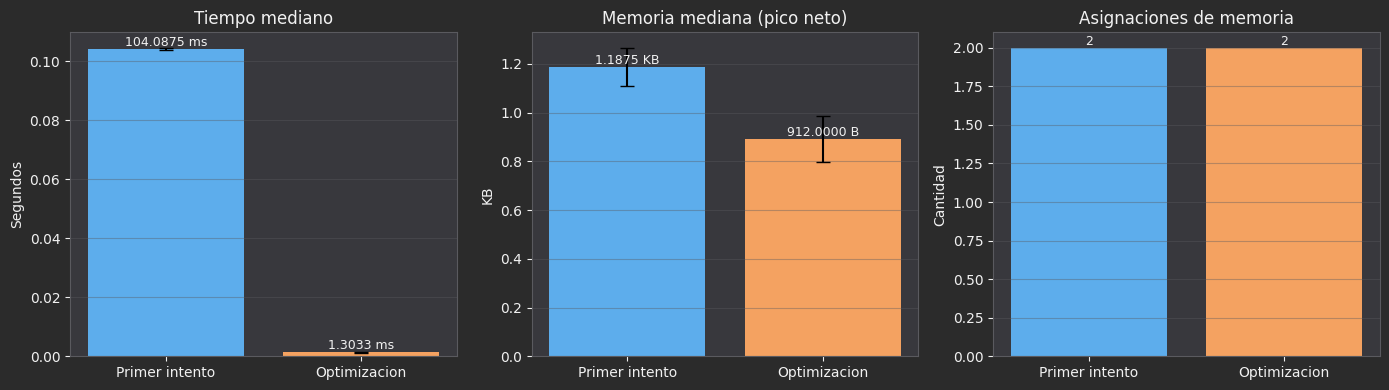

{'Primer intento': {'resultado': 906609,
  'consistente': True,
  'tiempos': [0.10455537900000023,
   0.1039973780000003,
   0.10417765499999998,
   0.10451359400000015,
   0.10439245500000016,
   0.10361098200000018,
   0.10377178099999984,
   0.10355283800000015],
  'memorias': [1.265625, 1.203125, 1.171875, 1.078125],
  'asignaciones': [2, 2, 3, 3],
  'repeticiones': 1},
 'Optimizacion': {'resultado': 906609,
  'consistente': True,
  'tiempos': [0.0013234370000000163,
   0.0014101923000000127,
   0.0013021123000000133,
   0.0013064410000000136,
   0.0013040000000000163,
   0.001302496799999986,
   0.0013025580999999954,
   0.0012971601999999915],
  'memorias': [0.984375, 0.921875, 0.859375, 0.765625],
  'asignaciones': [2, 2, 2, 2],
  'repeticiones': 10}}

In [3]:
from lib.utils import comparar_metodos

comparar_metodos(primer_intento, optimizacion)